In [10]:
install.packages(c("spectrolab", "CWT", "signal", "ggplot2", "dplyr", "pls", "caret"))
install.packages("CWT")
install.packages("signal")
install.packages("doParallel")
install.packages("foreach")
install.packages("pls")
install.packages("caret")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [115]:
meta <- read.csv("metadata.csv")
spectra <- read.csv("spectra_aggregated.csv")

In [116]:
library(spectrolab)
library(CWT)
library(signal)
library(ggplot2)
library(dplyr)
library(pls)
library(caret)
library(doParallel)
library(foreach)
library(stringr)

In [117]:
# subselect
colnames(spectra) <- str_replace(colnames(spectra), "X", "")

# 400 - 2400 nm, by 5 nm resolution
wvl <- seq(400, 2400, by=5)
spectra <- spectra[, c("filename", as.character(wvl))]
print(dim(spectra))


[1] 1537  402


In [118]:
row <- spectra[1, -1]
r <- head(row)
r

,400,405,410,415,420,425,430,435,440,445,⋯,2355,2360,2365,2370,2375,2380,2385,2390,2395,2400
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.03550501,0.03487026,0.03426713,0.03402691,0.03425298,0.03491078,0.03574747,0.03661993,0.03766736,0.03890705,⋯,0.259995,0.2631362,0.2657932,0.2670622,0.26731,0.2670259,0.2665551,0.2658607,0.2648435,0.2634465


n_samples   n_bands 
     1537       401 


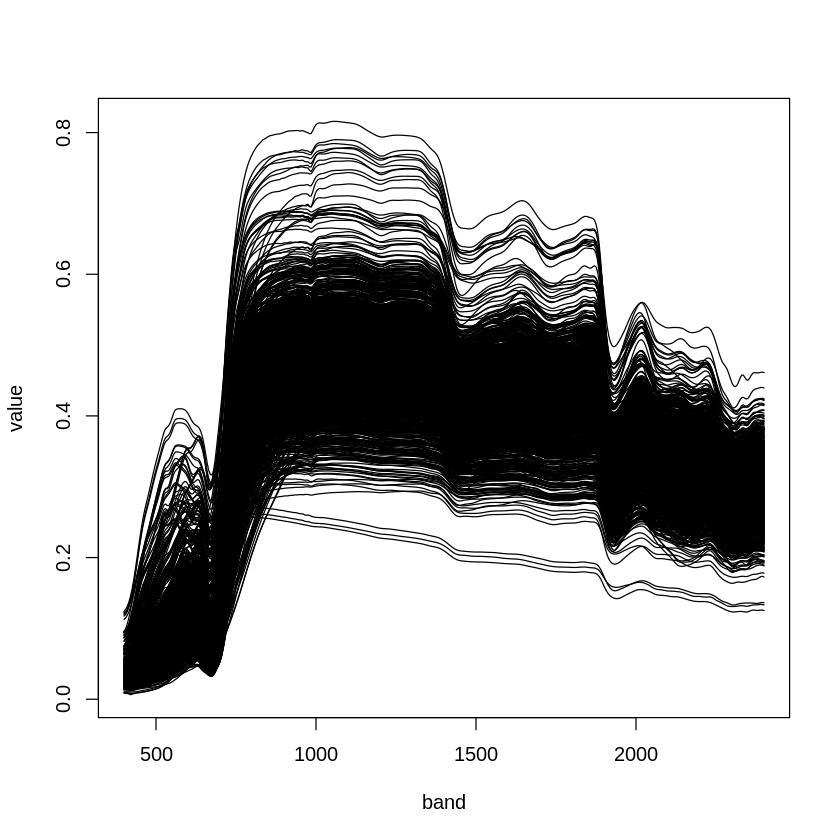

In [119]:
raw <- as_spectra(spectra, name_idx=1)
plot(raw)
print(dim(raw))

In [ ]:
# smooth


Vector nomalizing spectra...

Note that y values will not be true values anymore!



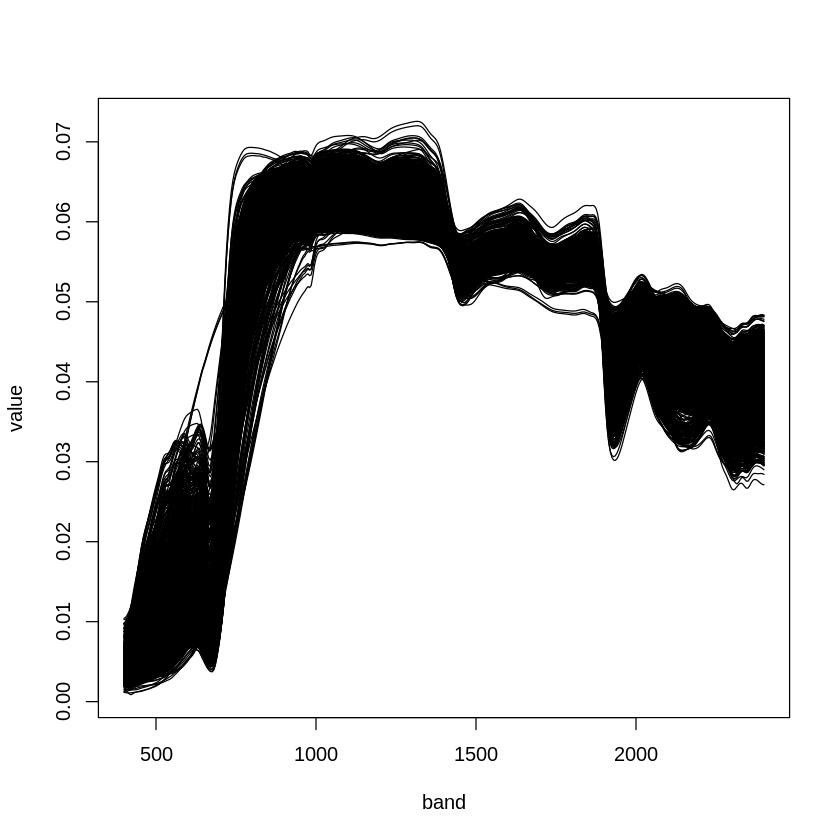

In [120]:
# vector normalize

vnorm <- normalize(raw)
plot(vnorm)

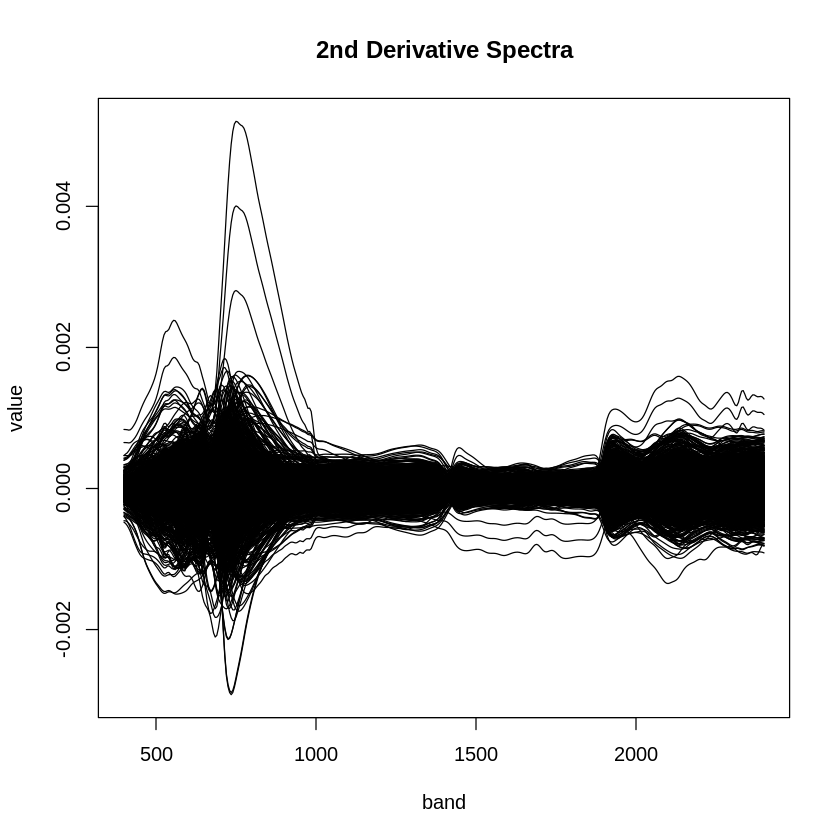

In [125]:
# 2nd derivative

mat <- as.data.frame(vnorm)

deriv2.spec <- mat[, 3:ncol(mat)]
#print(deriv2.spec)
deriv2.spec.meta <- mat[, 2]

deriv2.spec <- as.data.frame(apply(deriv2.spec, 2, FUN=sgolayfilt, p=3, n=11, m=2, ts=1))

d2spec <- as_spectra(deriv2.spec)
plot(d2spec, main="2nd Derivative Spectra")

In [122]:
# continuous wavelet transform (example on the first spectrum)
# Using Mexican Hat Wavelet (mexh) or similar depending on the CWT package
scales <- seq(1, 10, by=1)

cwt_spec <- cwt(deriv2.spec, scales, variance=1, summed_wavelet=FALSE, threads=1L)

cwt1 <- cwt_spec[,,1]
print(length(cwt1))

# Plot the CWT coefficients for the first spectrum
#image(cwt_result, main="CWT Coefficients (First Spectrum)", xlab="Band Index", ylab="Scale")

[1] 616337


In [124]:
dim(cwt_spec)

[1] 1537  401   10

[1] 401
[1] 10
[1] 401  10


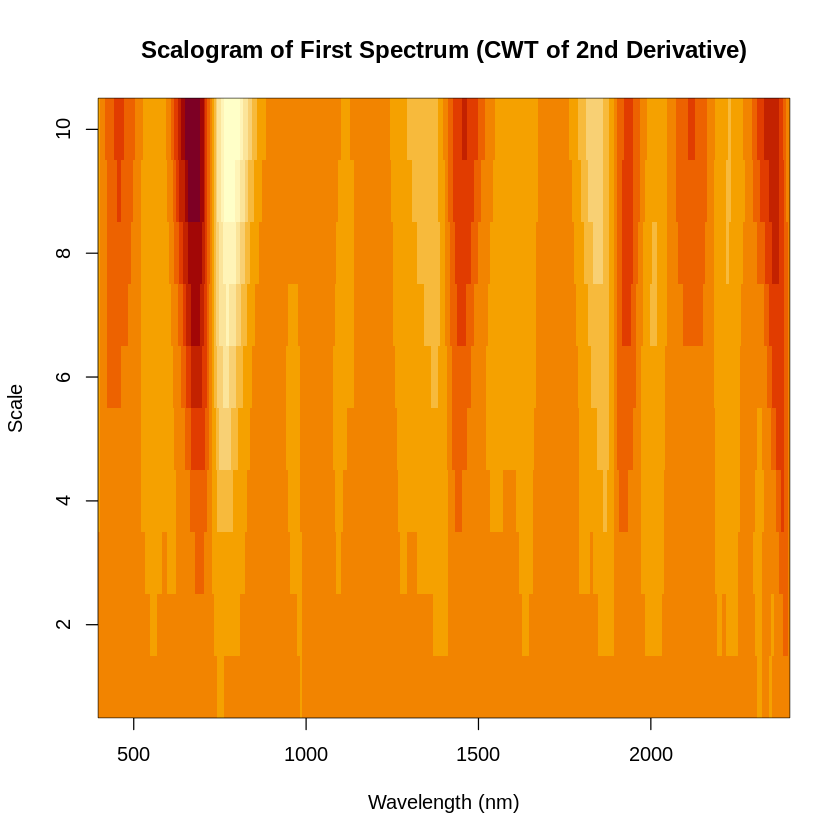

In [123]:
wvl_for_deriv2 <- wvl[2:length(wvl)] # Adjust wvl to match the 400 columns of deriv2.spec

# Extract CWT coefficients for the FIRST SAMPLE (across all wavelengths and scales)
# cwt_spec dimensions: [wavelengths, scales, samples]
cwt_coefficients_for_first_sample <- cwt_spec[,,1] # This is a [wavelengths, scales] matrix (400x10)

# The 'image' function expects 'z' to have dimensions [length(y), length(x)]
# Here, x = wvl_for_deriv2 (length 400) and y = scales (length 10)
# So, z needs to be [10, 400]
print(length(wvl))
print(length(scales))
print(dim(cwt_spec[1,,]))


image(x = wvl,
      y = scales,
      z = cwt_spec[1,,], # Transpose to get [scales, wavelengths]
      xlab = "Wavelength (nm)",
      ylab = "Scale",
      main = "Scalogram of First Spectrum (CWT of 2nd Derivative)")

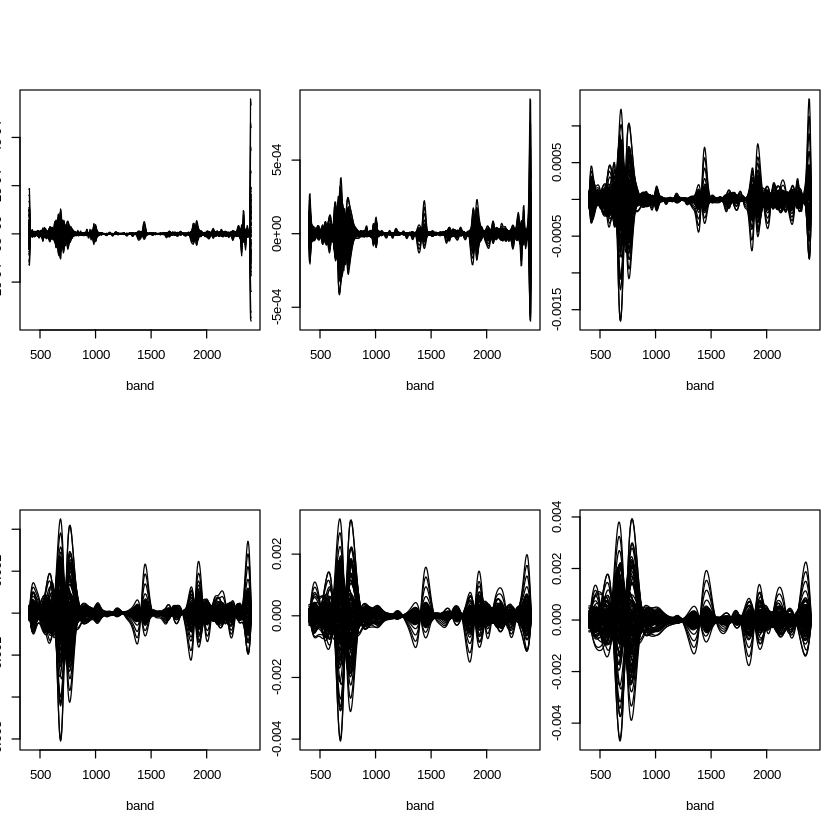

In [21]:
# plotting out cwt individual scales
par(mfrow=c(2, 3), pin=c(2,2))

cwt1 <- cwt_spec[,,1]

cwt1.spec <- as.data.frame(cwt1)
colnames(cwt1.spec) <- wvl

cwt1.spec <- as_spectra(cwt1.spec)

plot(cwt1.spec)


cwt1 <- cwt_spec[,,2]

cwt1.spec <- as.data.frame(cwt1)
colnames(cwt1.spec) <- wvl

cwt1.spec <- as_spectra(cwt1.spec)

plot(cwt1.spec)


cwt1 <- cwt_spec[,,4]

cwt1.spec <- as.data.frame(cwt1)
colnames(cwt1.spec) <- wvl

cwt1.spec <- as_spectra(cwt1.spec)

plot(cwt1.spec)


cwt1 <- cwt_spec[,,6]

cwt1.spec <- as.data.frame(cwt1)
colnames(cwt1.spec) <- wvl

cwt1.spec <- as_spectra(cwt1.spec)

plot(cwt1.spec)


cwt1 <- cwt_spec[,,8]

cwt1.spec <- as.data.frame(cwt1)
colnames(cwt1.spec) <- wvl

cwt1.spec <- as_spectra(cwt1.spec)

plot(cwt1.spec)


cwt1 <- cwt_spec[,,10]

cwt1.spec <- as.data.frame(cwt1)
colnames(cwt1.spec) <- wvl

cwt1.spec <- as_spectra(cwt1.spec)

plot(cwt1.spec)

In [22]:
# export
# raw, vnorm, cwt_spec, deriv2.spec

write.csv(raw, "rawspec.csv", quote=F, row.names=F)
write.csv(vnorm, "vnormspec.csv", quote=F, row.names=F)
deriv2.spec <- cbind(deriv2.spec.meta, deriv2.spec)
colnames(deriv2.spec) <- c("filename", wvl)
write.csv(deriv2.spec, "deriv2spec.csv", quote=F, row.names=F)
for (x in scales) {
  curr_cwt <- cwt_spec[,,x]
  curr_cwt <- cbind(deriv2.spec.meta, curr_cwt)
  colnames(curr_cwt) <- c("filename", wvl)
  write.csv(cwt_spec, paste0("cwtspec_scale", x, ".csv"), quote=F, row.names=F)
}

In [23]:
# set up data

rawspec <- read.csv("rawspec.csv")
vnormspec <- read.csv("vnormspec.csv")
deriv2spec <- read.csv("deriv2spec.csv")

In [130]:
metadata_train <- read.csv("metadata_train.csv")
metadata_test <- read.csv("metadata_test.csv")

Warning message in file(file, "rt"):
“cannot open file 'metadata_train.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection
